# Descriptive (Spatial) Analytics

This notebook analyses the spatial and temporal structure of Chicago taxi demand in 2024, addressing Task 2 of the AAA26 assignment. We proceed through four themes: temporal demand patterns, trip characteristics, spatial demand concentration, and hotspot detection.

All data is loaded via `load_taxi_data()` from `scripts/helpers/datasets.py`, which applies the full preprocessing pipeline documented in `01_data_preparation.ipynb`. Community area boundaries are loaded separately from `data/raw/community_areas.geojson`.

**Note on spatial precision.** The columns `pickup_centroid_latitude/longitude` and `dropoff_centroid_latitude/longitude` record the **centroid of the census tract** where each trip started or ended, not the exact GPS coordinates of the pickup. All trips originating in the same census tract therefore share identical centroid coordinates. We account for this constraint explicitly in the H3 hexagonal analysis (Section 5) by using only grid resolutions that are consistent with census-tract-level precision.

In [1]:
from pathlib import Path
import sys

ROOT_DIR = Path().resolve().parent
sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import seaborn as sns
import h3
from shapely.geometry import Polygon
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde

from scripts.helpers.datasets import load_taxi_data

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
df = load_taxi_data(preprocessed=True)

CA_PATH = ROOT_DIR / 'data' / 'raw' / 'community_areas.geojson'
ca = gpd.read_file(CA_PATH)
ca['area_num'] = ca['area_numbe'].astype(int)
ca_name_map = ca.set_index('area_num')['community'].to_dict()

df['pickup_hour']  = df['trip_start_timestamp'].dt.hour
df['pickup_dow']   = df['trip_start_timestamp'].dt.day_of_week  # 0 = Mon
df['pickup_month'] = df['trip_start_timestamp'].dt.month
df['pickup_year']  = df['trip_start_timestamp'].dt.year
df['pickup_ca']    = df['pickup_community_area'].astype('Int64')
df['dropoff_ca']   = df['dropoff_community_area'].astype('Int64')

print(f'Loaded {len(df):,} trips.')
print(f'Date range: {df["trip_start_timestamp"].min().date()} to {df["trip_start_timestamp"].max().date()}')

Loaded 6,014,433 trips.
Date range: 2024-01-01 to 2026-04-30


## 1  Temporal Demand Patterns

Before examining where trips occur, we establish *when* they occur. We look at four levels of temporal aggregation: hour of day, day of week, month of year, and year. We then compare three time-series bin sizes (1-hour, 4-hour, daily) to show how the choice of temporal resolution shapes which patterns are visible.

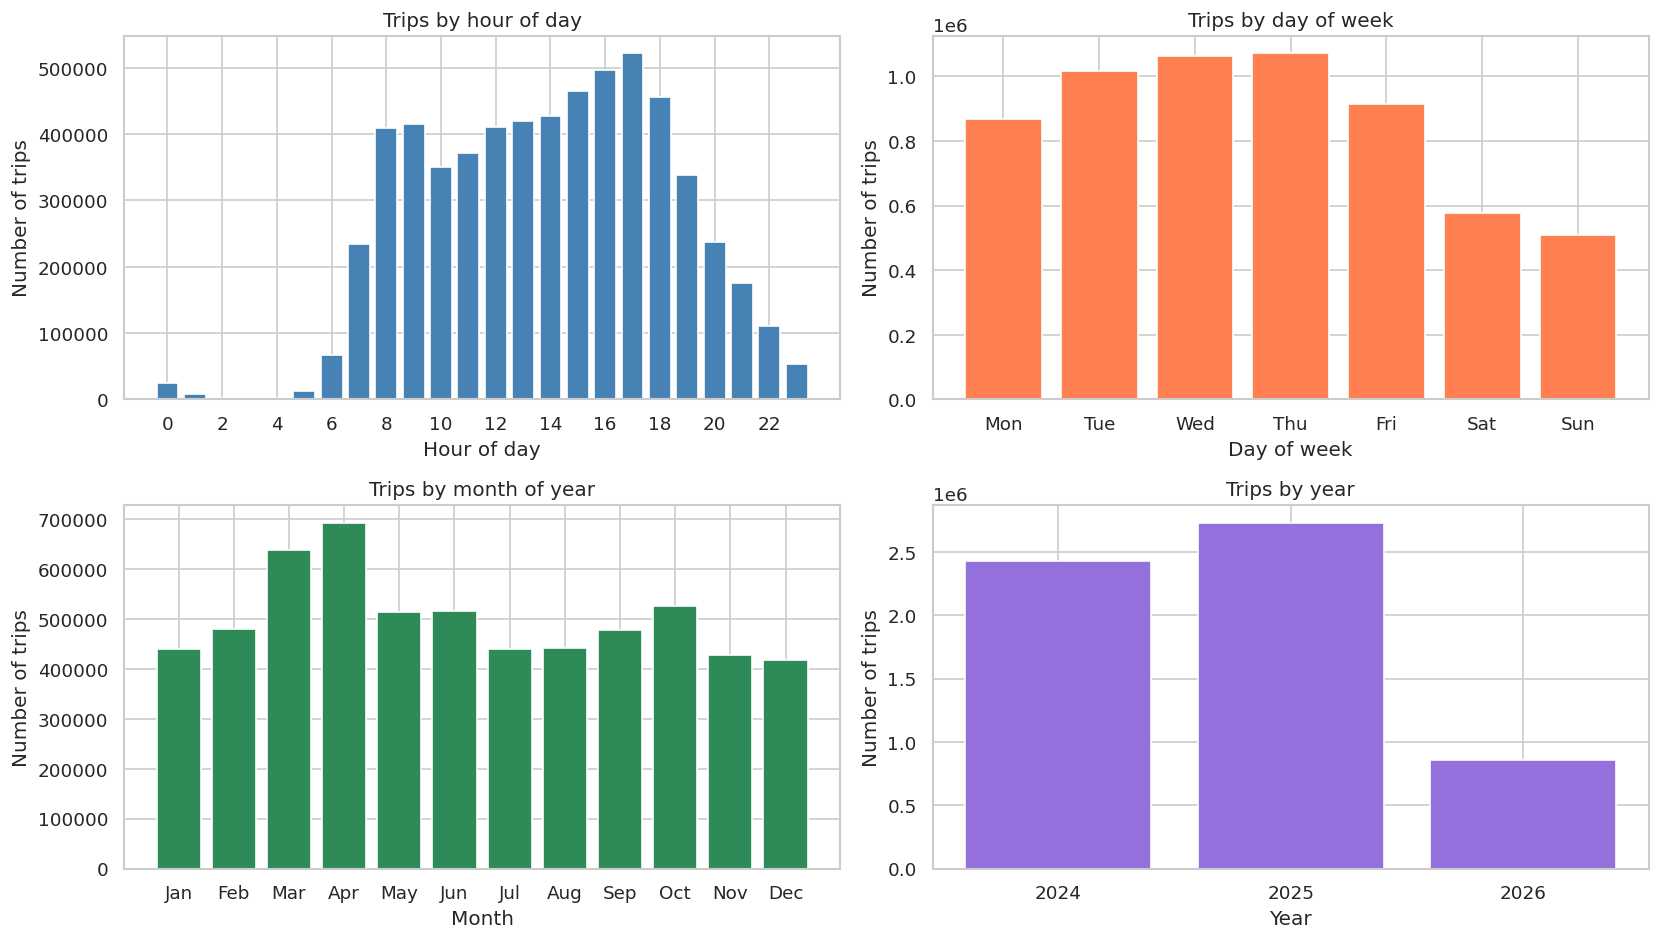

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# Hour of day
hourly = df.groupby('pickup_hour').size()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Number of trips')
axes[0].set_title('Trips by hour of day')
axes[0].set_xticks(range(0, 24, 2))

# Day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow = df.groupby('pickup_dow').size()
axes[1].bar(dow_labels, dow.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('Number of trips')
axes[1].set_title('Trips by day of week')

# Month of year
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly = df.groupby('pickup_month').size()
axes[2].bar(
    [month_labels[m - 1] for m in monthly.index],
    monthly.values, color='seagreen', edgecolor='white'
)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Number of trips')
axes[2].set_title('Trips by month of year')

# Year
yearly = df.groupby('pickup_year').size()
axes[3].bar([str(y) for y in yearly.index], yearly.values,
            color='mediumpurple', edgecolor='white')
axes[3].set_xlabel('Year')
axes[3].set_ylabel('Number of trips')
axes[3].set_title('Trips by year')

plt.tight_layout()
plt.show()

The hour-of-day distribution shows the characteristic bimodal shape of urban taxi demand: a morning rush followed by a deeper evening peak, with a pronounced late-night bump that likely intensifies on weekends. Day-of-week volumes are relatively stable across weekdays with a modest weekend shift. The monthly panel reveals seasonal variation: winter months tend to be quieter as residents substitute other transport modes, while spring and autumn show higher activity. The year breakdown confirms the temporal coverage of the dataset.

The three time-series illustrate why temporal resolution matters. At hourly granularity, individual rush-hour peaks and quiet overnight windows are sharply defined. At 4-hour granularity, the morning/evening rhythm is still clear but the precise peak hour blurs into a broader wave. At daily granularity, week-level periodicity and public holiday troughs become easier to identify. For the spatio-temporal cross-analysis in Section 6 we use hourly bins, since demand can differ substantially even between adjacent hours during peak periods.

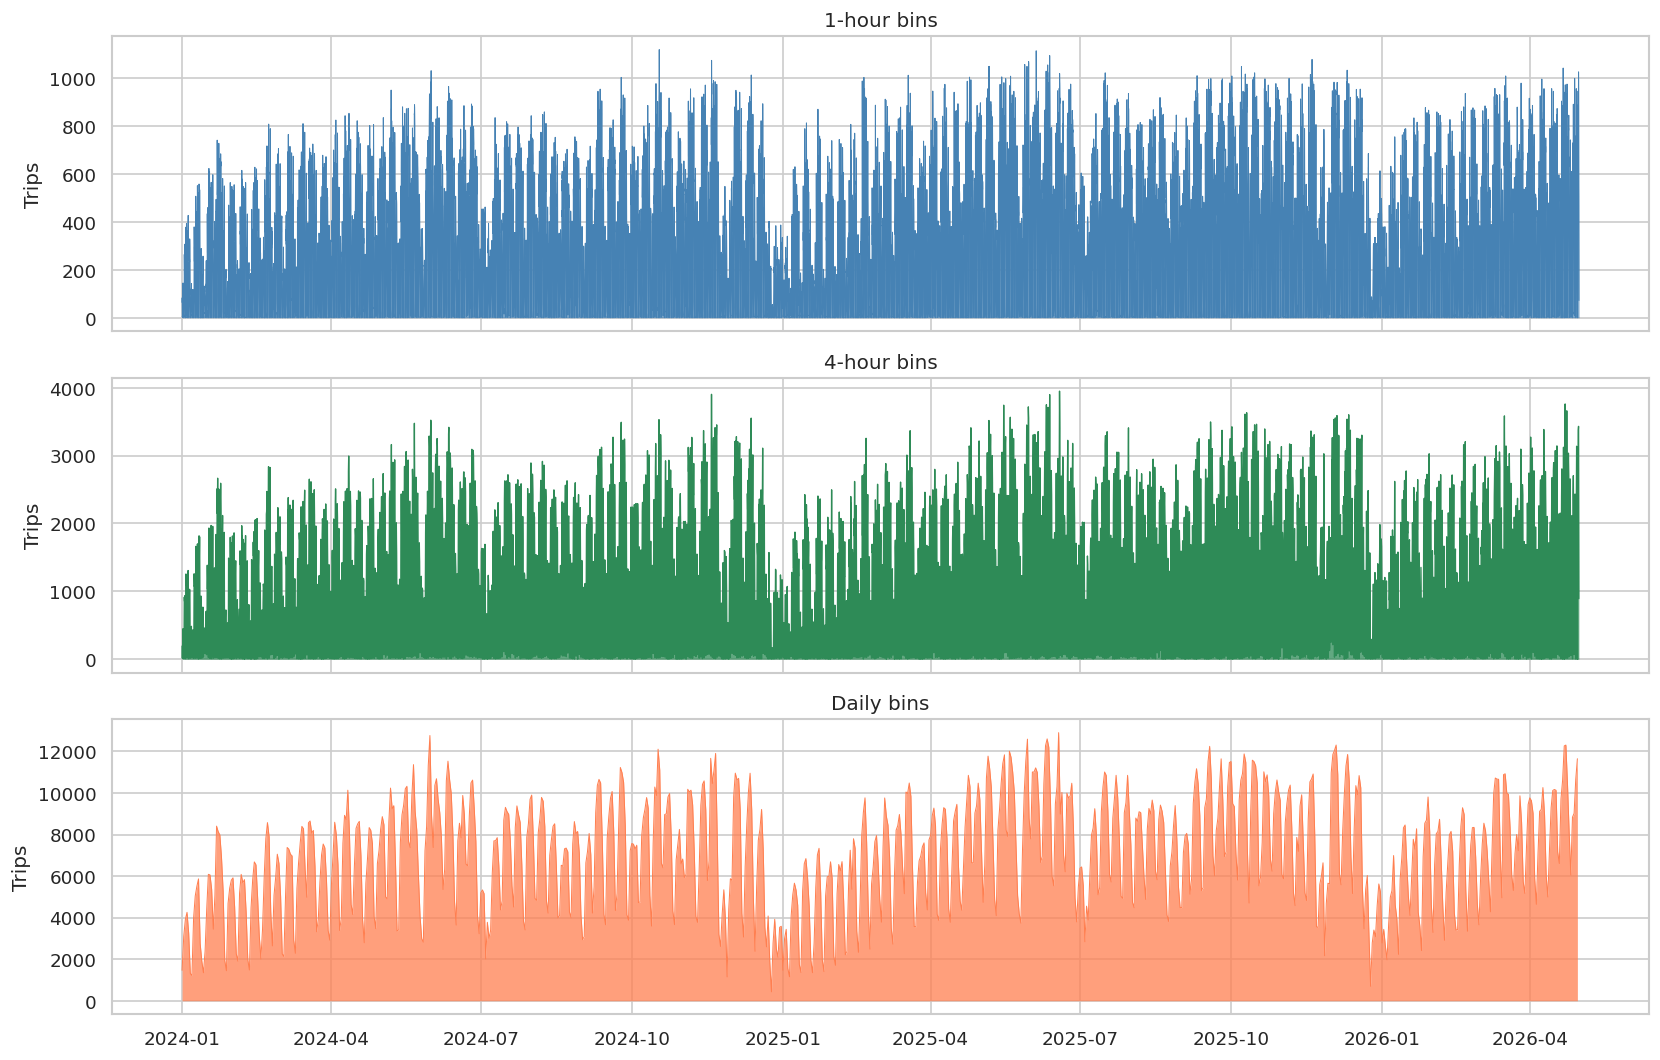

In [4]:
# Temporal bin comparison: 1h vs 4h vs daily
ts = df.set_index('trip_start_timestamp').sort_index()

bin_1h = ts.resample('1h').size()
bin_4h = ts.resample('4h').size()
bin_1d = ts.resample('1D').size()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].fill_between(bin_1h.index, bin_1h.values, color='steelblue', alpha=0.75, lw=0)
axes[0].plot(bin_1h.index, bin_1h.values, lw=0.6, color='steelblue')
axes[0].set_ylabel('Trips')
axes[0].set_title('1-hour bins')

axes[1].fill_between(bin_4h.index, bin_4h.values, color='seagreen', alpha=0.75, lw=0)
axes[1].plot(bin_4h.index, bin_4h.values, lw=0.8, color='seagreen')
axes[1].set_ylabel('Trips')
axes[1].set_title('4-hour bins')

# Daily: use fill_between so 365 bars don't collapse to hairlines
axes[2].fill_between(bin_1d.index, bin_1d.values, color='coral', alpha=0.75, lw=0)
axes[2].plot(bin_1d.index, bin_1d.values, lw=0.6, color='coral')
axes[2].set_ylabel('Trips')
axes[2].set_title('Daily bins')

plt.tight_layout()
plt.show()

Both distributions are strongly right-skewed. The mean is pulled well above the median by a long tail of long-duration or long-distance trips (airport runs, slow-traffic corridors). The bulk of Chicago taxi rides are short: most trips are under 15 minutes and under 5 miles, consistent with inner-city point-to-point movement. The mean–median gap is a useful reminder that arithmetic averages misrepresent the typical experience; the median is the more robust summary for most planning purposes.

The fare distribution mirrors trip length: concentrated at low values with a long tail. The tip distribution has a sharp spike at zero (cash trips and non-tipping passengers), followed by a secondary concentration around 20% of fare, corresponding to the default tip suggestion shown on card payment terminals. The gap between median and mean tip reflects this bimodal structure. `trip_total` can exceed `fare + tips` due to tolls and extras such as airport surcharges, which explains the slight right-shift in the total panel relative to fare alone.

The idle time distribution is heavily right-skewed: many inter-trip gaps are short, as drivers in high-demand areas find their next passenger quickly, but a substantial tail of longer waits reflects shift changes, meal breaks, or low-demand windows. The mean exceeding the median by a noticeable margin confirms this asymmetry. Areas with consistently short idle times are those where passive demand density is high enough that repositioning cruises are rarely needed, which has direct implications for driver earnings and passenger wait times.

## 2  Trip Characteristics

We characterise individual trip properties (duration, distance, and cost) before turning to spatial analysis. Understanding the typical trip profile matters because distributional shape affects which statistics are appropriate for later aggregations, and because idle time (the gap between consecutive trips for the same taxi) is a direct proxy for driver utilisation and cruising behaviour.

All distributions are capped at the 99th percentile to keep axes legible; extreme outliers such as cross-city airport runs exist but represent a small minority of trips.

Demand is geographically concentrated: a small number of community areas account for a disproportionate share of all pickups and dropoffs. The Loop and its immediate neighbours dominate, reflecting the density of hotels, offices, restaurants, and entertainment venues. O'Hare (area 76, northwestern corner) stands out as a high-volume generator that is spatially isolated from the central cluster. The pickup and dropoff maps are broadly symmetric, but airports show a notable asymmetry: many trips originate there (deplaning passengers) but fewer terminate there relative to the Loop, where both arrivals and departures are common.

The ranked bar chart makes the long-tail structure explicit: the top handful of areas each account for hundreds of thousands of trips, while the bottom third of community areas collectively contribute only a small fraction of total volume. The pickup and dropoff rankings are closely correlated, with high-demand areas attracting journeys in both directions, though minor rank differences can hint at one-directional flows worth investigating in the OD analysis below.

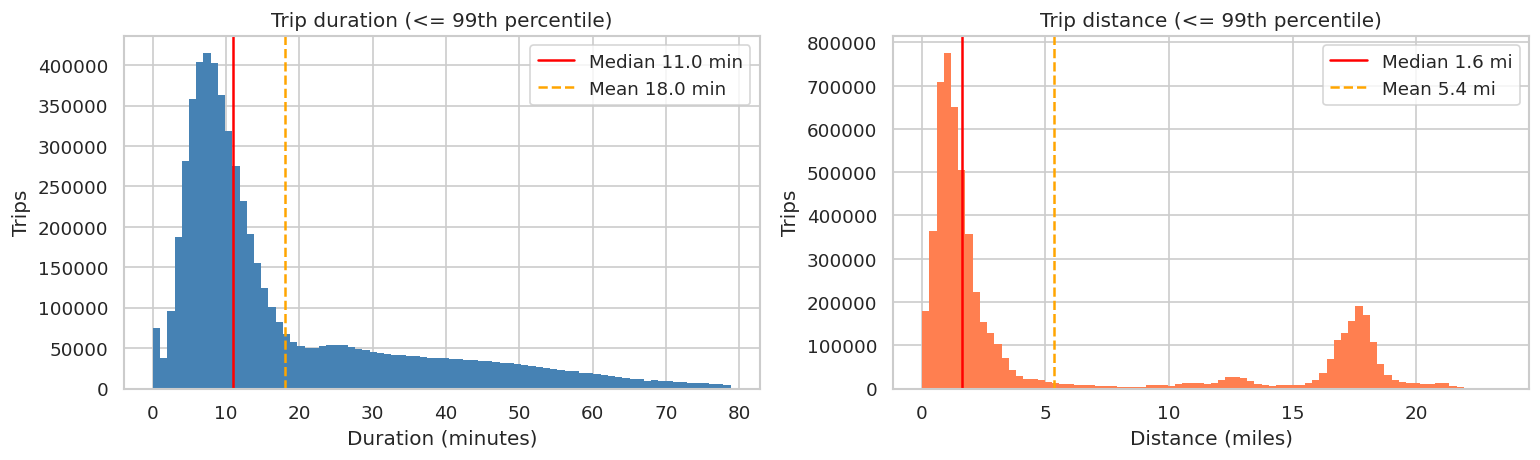

In [5]:
dur  = df['trip_seconds'].dropna()
dur  = dur[(dur > 0) & (dur <= dur.quantile(0.99))]
dist = df['trip_miles'].dropna()
dist = dist[(dist > 0) & (dist <= dist.quantile(0.99))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(dur / 60, bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(dur.median() / 60, color='red', lw=1.5,
                label=f'Median {dur.median()/60:.1f} min')
axes[0].axvline(dur.mean() / 60, color='orange', lw=1.5, linestyle='--',
                label=f'Mean {dur.mean()/60:.1f} min')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Trips')
axes[0].set_title('Trip duration (<= 99th percentile)')
axes[0].legend()

axes[1].hist(dist, bins=80, color='coral', edgecolor='none')
axes[1].axvline(dist.median(), color='red', lw=1.5,
                label=f'Median {dist.median():.1f} mi')
axes[1].axvline(dist.mean(), color='orange', lw=1.5, linestyle='--',
                label=f'Mean {dist.mean():.1f} mi')
axes[1].set_xlabel('Distance (miles)')
axes[1].set_ylabel('Trips')
axes[1].set_title('Trip distance (<= 99th percentile)')
axes[1].legend()

plt.tight_layout()
plt.show()

The diagonal of the OD matrix represents within-area trips, which are high for large, mixed-use areas like the Loop where passengers travel short distances entirely within the same community area. Off-diagonal concentrations reveal the strongest inter-area corridors. Symmetric high-volume cells (strong colour in both the (A→B) and (B→A) positions) identify bidirectional commuter corridors; asymmetric cells may reflect directional flows such as morning inbound to the CBD or evening outbound to residential areas.

The flow map makes the geographic structure of the OD matrix immediately visible. The thickest and brightest lines converge on the central business district, confirming its role as the dominant hub of the city's taxi network. Most high-volume corridors are geographically short, consistent with the trip distance distributions in Section 2, but a few long-distance arcs connecting the Loop to O'Hare or Midway airports are clearly distinguishable by their trajectory across the city.

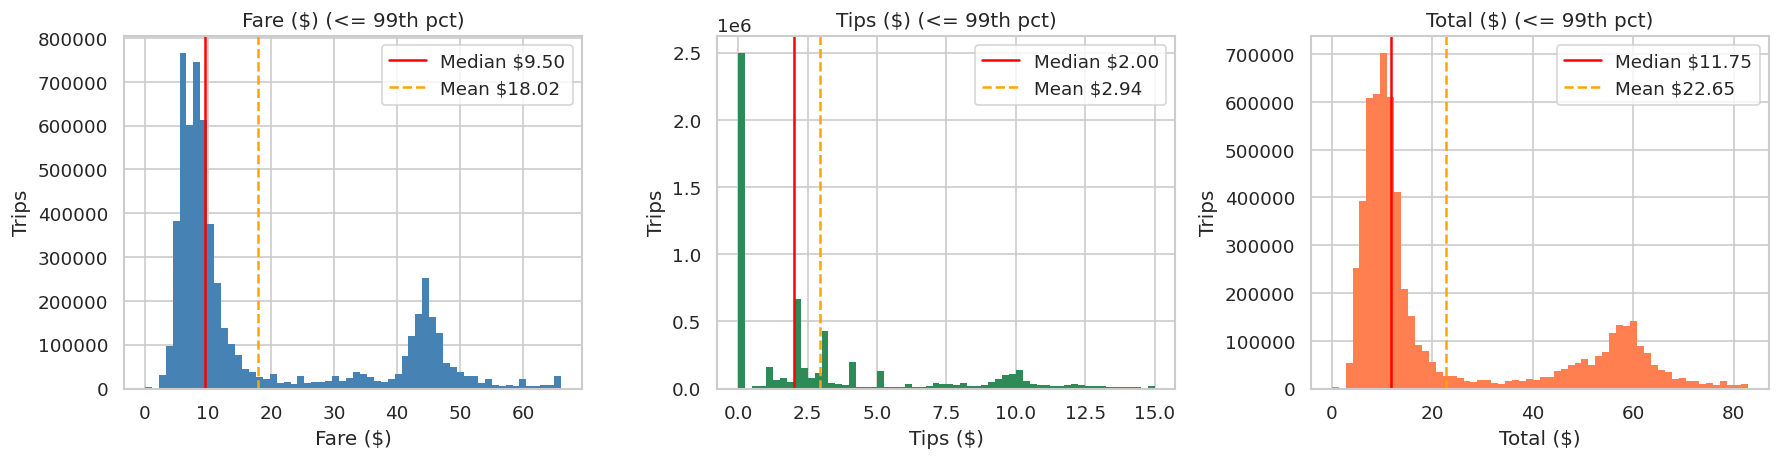

Trips with any tip:  58.6%
Median tip rate:     23.6%


In [6]:
p99 = lambda s: s[s <= s.quantile(0.99)]

fare  = p99(df['fare'].dropna())
tips  = p99(df['tips'].dropna())
total = p99(df['trip_total'].dropna())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, label, color in zip(
    axes,
    [fare, tips, total],
    ['Fare ($)', 'Tips ($)', 'Total ($)'],
    ['steelblue', 'seagreen', 'coral']
):
    ax.hist(data, bins=60, color=color, edgecolor='none')
    ax.axvline(data.median(), color='red', lw=1.5,
               label=f'Median ${data.median():.2f}')
    ax.axvline(data.mean(), color='orange', lw=1.5, linestyle='--',
               label=f'Mean ${data.mean():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Trips')
    ax.set_title(f'{label} (<= 99th pct)')
    ax.legend()

plt.tight_layout()
plt.show()

tipped = df[df['fare'] > 0].copy()
tipped['tip_rate'] = tipped['tips'] / tipped['fare']
print(f"Trips with any tip:  {(tipped['tips'] > 0).mean():.1%}")
print(f"Median tip rate:     {tipped.loc[tipped['tips'] > 0, 'tip_rate'].median():.1%}")

At resolution 5, Chicago fits into just a handful of hexagons, useful for comparing broad city sectors (North Side vs. South Side vs. central) but too coarse to reveal neighbourhood-level variation. Resolution 6 begins to expose the concentration along the lakefront corridor. Resolution 7 approaches community-area granularity and provides a spatially regular alternative to the Section 3 choropleth, avoiding the visual dominance that large-polygon peripheral areas exert in standard polygon maps.

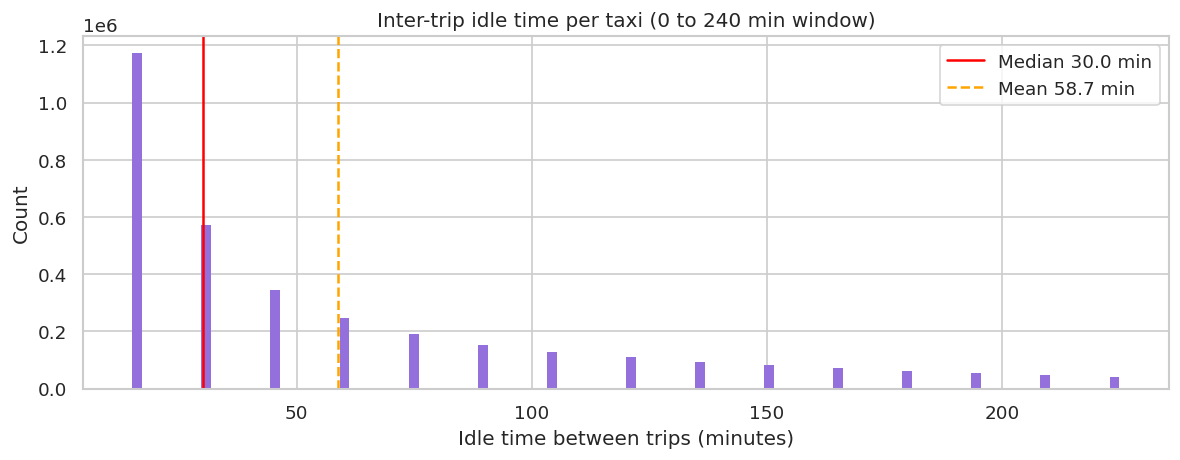

In [7]:
# Idle time between consecutive trips per taxi (shift approach -- avoids slow groupby.apply)
trips_s = (
    df[['taxi_id', 'trip_start_timestamp', 'trip_end_timestamp']]
      .dropna()
      .sort_values(['taxi_id', 'trip_start_timestamp'])
      .copy()
)
trips_s['next_start'] = trips_s.groupby('taxi_id')['trip_start_timestamp'].shift(-1)
trips_s['idle_min'] = (
    (trips_s['next_start'] - trips_s['trip_end_timestamp']).dt.total_seconds() / 60
)

idle = trips_s['idle_min'].dropna()
idle = idle[(idle > 0) & (idle < 240)]  # 0 to 4-hour window

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(idle, bins=100, color='mediumpurple', edgecolor='none')
ax.axvline(idle.median(), color='red', lw=1.5,
           label=f'Median {idle.median():.1f} min')
ax.axvline(idle.mean(), color='orange', lw=1.5, linestyle='--',
           label=f'Mean {idle.mean():.1f} min')
ax.set_xlabel('Idle time between trips (minutes)')
ax.set_ylabel('Count')
ax.set_title('Inter-trip idle time per taxi (0 to 240 min window)')
ax.legend()
plt.tight_layout()
plt.show()

The normalised heatmap reveals distinct temporal archetypes that are hidden in the absolute count view. Airport areas (O'Hare, Midway) show pronounced early-morning and late-evening peaks aligned with flight schedules. The Loop and Near North Side follow an office-and-entertainment pattern: moderate morning activity, a lunchtime plateau, and a pronounced evening concentration. Residential areas on the North Side tend to show a sharper late-night peak consistent with bar and restaurant closing times. These differences in temporal profile suggest that demand forecasting and fleet positioning models should be conditioned on area type, not only on city-level aggregate cycles.

## 3  Spatial Demand by Community Area

Chicago is divided into 77 officially designated community areas, the coarsest spatial unit available in the dataset and a natural unit for planning and policy analysis. We aggregate trips by `pickup_community_area` and `dropoff_community_area` (imputed via spatial join where missing; see `01_data_preparation.ipynb`).

Two complementary views are shown: **choropleth maps** that convey geographic structure at a glance, and **ranked bar charts** that enable precise comparison of individual areas by volume.

BIC penalises model complexity more heavily than AIC and typically selects a more parsimonious *k*. The BIC-optimal value is used for the final model. Where BIC and AIC agree, the result is robust; where they diverge, the BIC value is preferred as it avoids overfitting to the spatial structure of a relatively small number of distinct census-tract centroid locations.

The GMM ellipses and KDE density surface are broadly consistent: both methods identify the same dominant hotspots. The Loop and Near North Side form the largest and densest cluster. O'Hare appears as a well-separated component in the northwest, reflecting its distinct demand pattern: high volume, long-distance trips tightly constrained to the airport footprint. Secondary clusters emerge along the lakefront corridor and around Midway airport on the southwest side.

The GMM adds interpretive value beyond the KDE through the covariance ellipses: elongated or tilted components can indicate directional demand aligned with major corridors. Where the two methods diverge, it typically reflects either the GMM's Gaussian shape assumption being too restrictive for an irregular cluster, or the KDE bandwidth smoothing over meaningful sub-structure within a dense area.

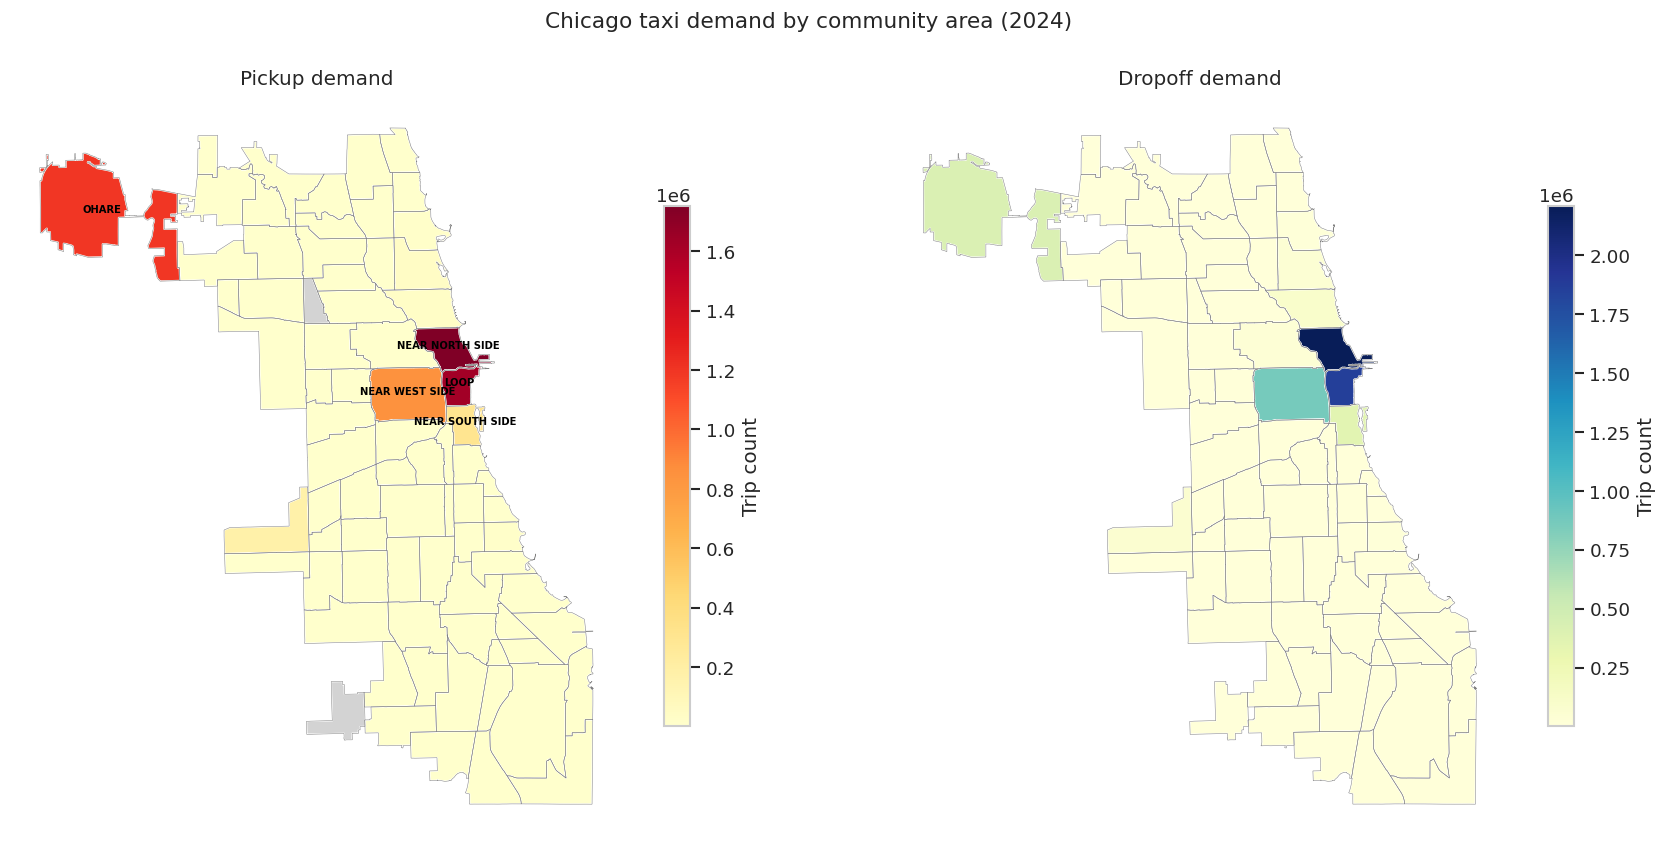

In [8]:
pickup_counts  = df['pickup_ca'].value_counts().rename('pickup_count')
dropoff_counts = df['dropoff_ca'].value_counts().rename('dropoff_count')

ca_map = ca.merge(
    pickup_counts.reset_index().rename(columns={'pickup_ca': 'area_num'}),
    on='area_num', how='left'
)
ca_map = ca_map.merge(
    dropoff_counts.reset_index().rename(columns={'dropoff_ca': 'area_num'}),
    on='area_num', how='left'
)

top5_pickup = ca_map.nlargest(5, 'pickup_count')

# Compute centroids in a projected CRS to suppress geographic CRS warning
_ca_proj = ca_map.to_crs(epsg=32616)
top5_centroids = _ca_proj.loc[top5_pickup.index].geometry.centroid.to_crs(epsg=4326)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, col, title, cmap in zip(
    axes,
    ['pickup_count', 'dropoff_count'],
    ['Pickup demand', 'Dropoff demand'],
    ['YlOrRd', 'YlGnBu']
):
    ca_map.plot(column=col, ax=ax, cmap=cmap, legend=True,
                legend_kwds={'label': 'Trip count', 'shrink': 0.7},
                missing_kwds={'color': 'lightgrey'})
    ca_map.boundary.plot(ax=ax, linewidth=0.3, color='grey')
    ax.set_title(title)
    ax.set_axis_off()

for (_, row), c in zip(top5_pickup.iterrows(), top5_centroids):
    axes[0].text(c.x, c.y, row['community'], fontsize=6, ha='center',
                 color='black', fontweight='bold')

plt.suptitle('Chicago taxi demand by community area (2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

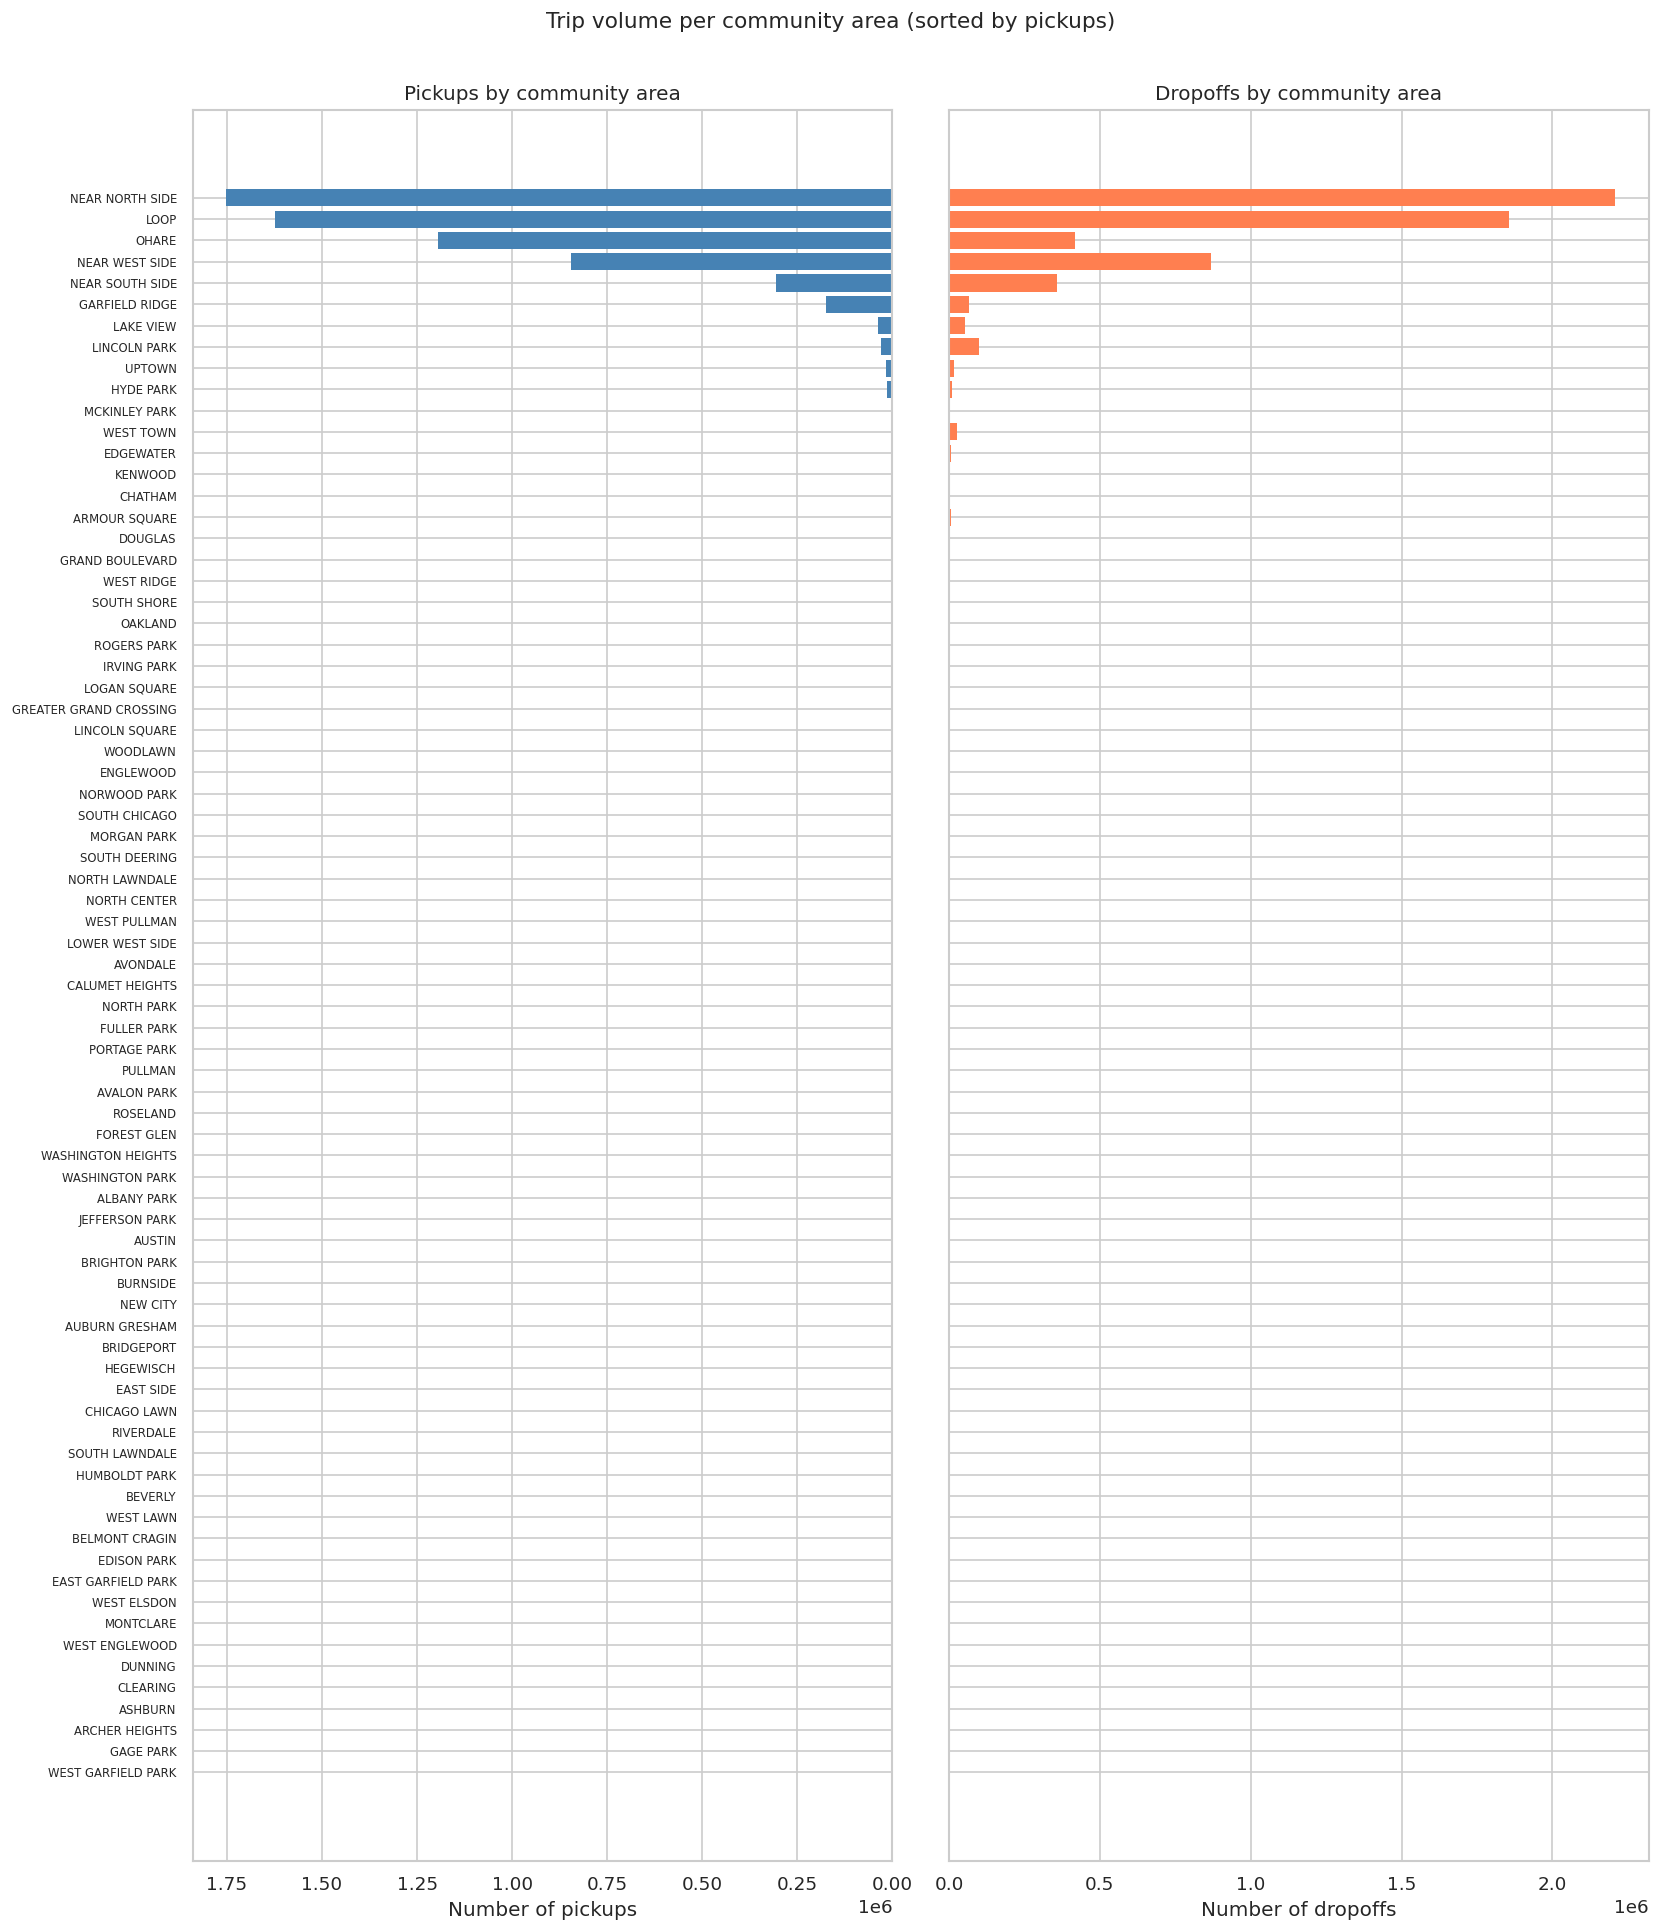

In [9]:
# Ranked bar chart: all community areas sorted by pickup count
ca_bar = (
    ca_map[['community', 'pickup_count', 'dropoff_count']]
      .dropna(subset=['pickup_count'])
      .sort_values('pickup_count', ascending=True)  # ascending so largest is at top
)

fig, axes = plt.subplots(1, 2, figsize=(14, 16), sharey=True)

y = range(len(ca_bar))

axes[0].barh(list(y), ca_bar['pickup_count'], color='steelblue', edgecolor='none')
axes[0].set_yticks(list(y))
axes[0].set_yticklabels(ca_bar['community'], fontsize=7)
axes[0].invert_xaxis()  # mirror layout: pickup grows left, dropoff grows right
axes[0].set_xlabel('Number of pickups')
axes[0].set_title('Pickups by community area')

axes[1].barh(list(y), ca_bar['dropoff_count'], color='coral', edgecolor='none')
axes[1].set_xlabel('Number of dropoffs')
axes[1].set_title('Dropoffs by community area')

fig.suptitle('Trip volume per community area (sorted by pickups)', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

## 4  Origin-Destination (OD) Flow Analysis

Community area demand counts show *how many* trips start or end in each area, but not *where those trips go*. OD analysis captures the full journey structure: which area pairs are most frequently connected, and whether demand is symmetric or directional.

We present two complementary views: a **heatmap matrix** for precise comparison of the top 20 areas by volume, and a **geographic flow map** where line width and colour encode trip volume between community area centroids (computed from polygon geometry in a projected CRS to avoid distortion).

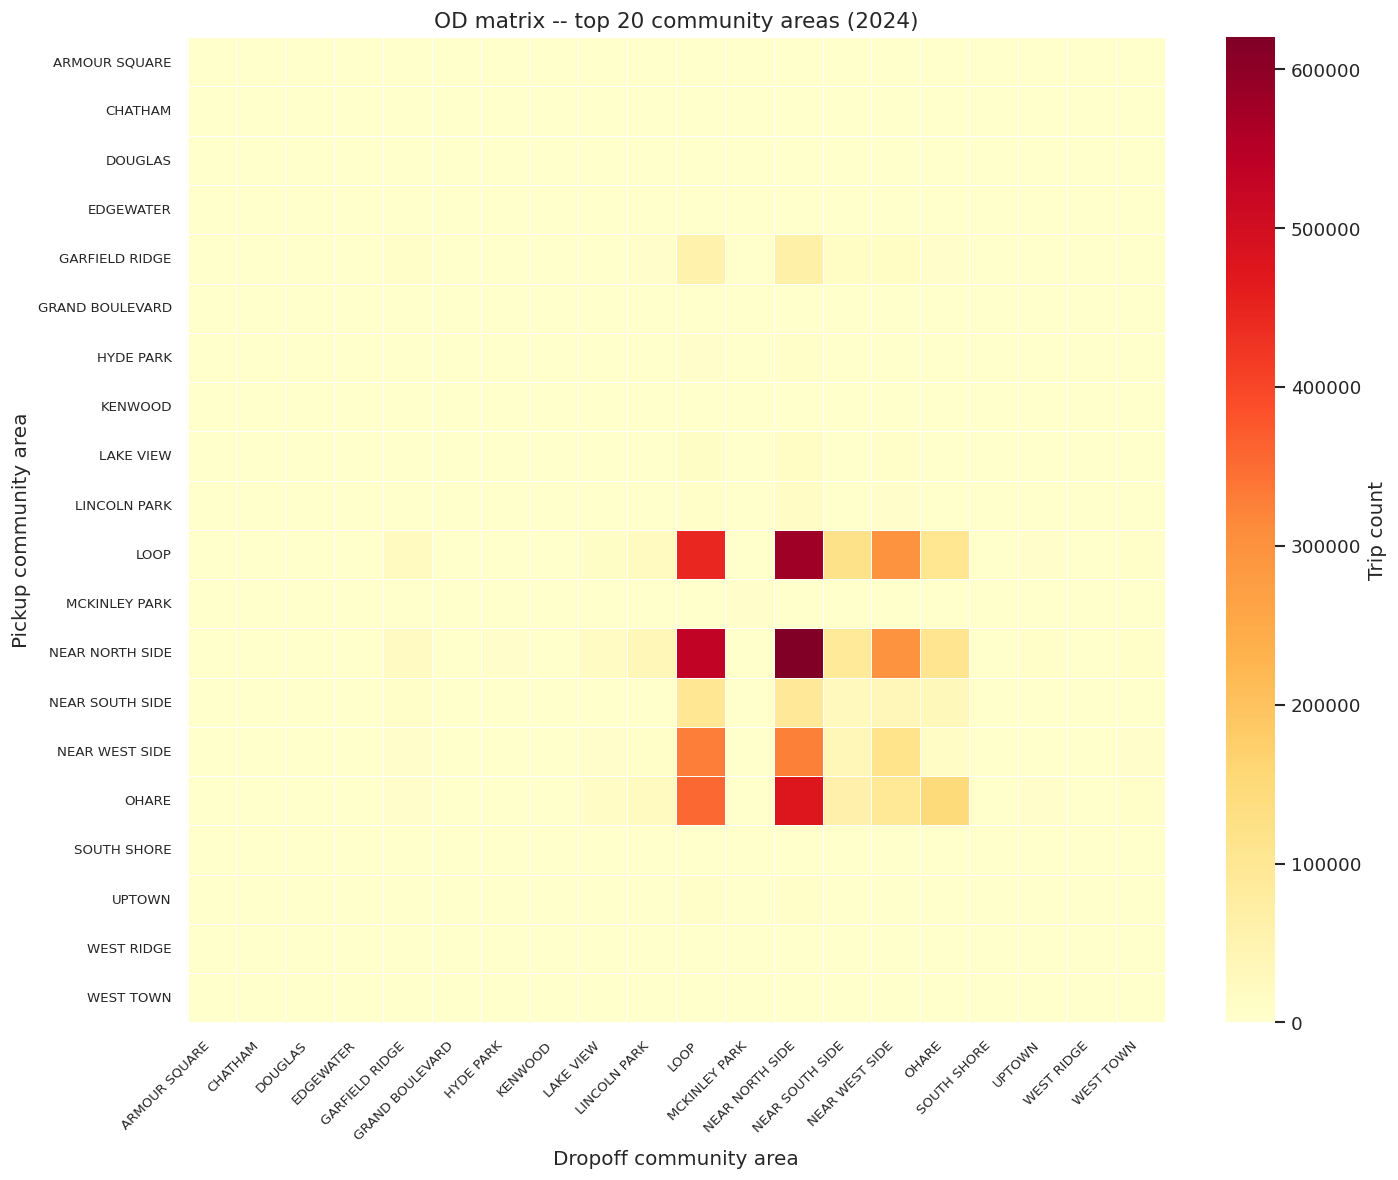

In [10]:
# OD matrix heatmap -- top 20 areas by pickup volume
od = (
    df.dropna(subset=['pickup_ca', 'dropoff_ca'])
      .groupby(['pickup_ca', 'dropoff_ca'])
      .size()
      .reset_index(name='count')
)

top_areas = df['pickup_ca'].value_counts().head(20).index.tolist()
od_top = od[
    od['pickup_ca'].isin(top_areas) & od['dropoff_ca'].isin(top_areas)
].copy()
od_top['pickup_name']  = od_top['pickup_ca'].map(ca_name_map)
od_top['dropoff_name'] = od_top['dropoff_ca'].map(ca_name_map)

od_pivot = od_top.pivot(
    index='pickup_name', columns='dropoff_name', values='count'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(od_pivot, ax=ax, cmap='YlOrRd',
            linewidths=0.3, cbar_kws={'label': 'Trip count'})
ax.set_title('OD matrix -- top 20 community areas (2024)', fontsize=13)
ax.set_xlabel('Dropoff community area')
ax.set_ylabel('Pickup community area')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

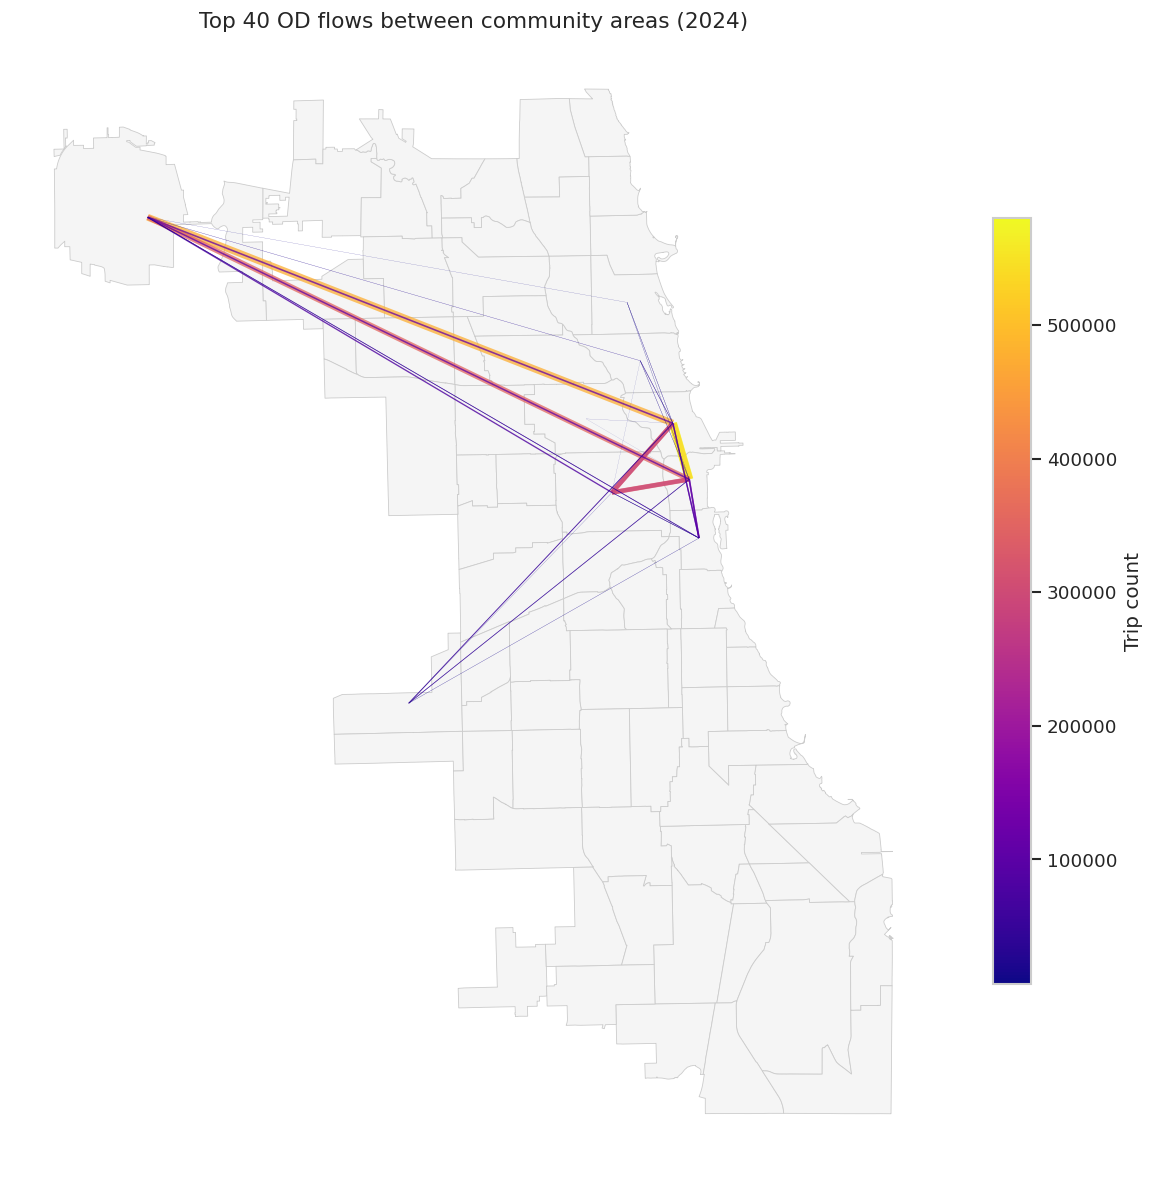

In [11]:
# OD flow map -- top 40 OD pairs (excluding self-loops)
# Project to UTM zone 16N for accurate centroids, then back to WGS84
_ca_proj = ca.to_crs(epsg=32616)
_centroids_4326 = _ca_proj.geometry.centroid.to_crs(epsg=4326)

ca_ctr = ca.copy()
ca_ctr['cx'] = _centroids_4326.x
ca_ctr['cy'] = _centroids_4326.y
centroid_map = ca_ctr.set_index('area_num')[['cx', 'cy']]

od_flow = od.merge(
    centroid_map.rename(columns={'cx': 'pcx', 'cy': 'pcy'}),
    left_on='pickup_ca', right_index=True
)
od_flow = od_flow.merge(
    centroid_map.rename(columns={'cx': 'dcx', 'cy': 'dcy'}),
    left_on='dropoff_ca', right_index=True
)
od_flow = od_flow[od_flow['pickup_ca'] != od_flow['dropoff_ca']]
top_od  = od_flow.nlargest(40, 'count')

segments = [[(r['pcx'], r['pcy']), (r['dcx'], r['dcy'])] for _, r in top_od.iterrows()]
widths   = (top_od['count'] / top_od['count'].max() * 5).values

norm   = mcolors.Normalize(vmin=top_od['count'].min(), vmax=top_od['count'].max())
cmap   = plt.cm.plasma
colors = [cmap(norm(v)) for v in top_od['count'].values]

fig, ax = plt.subplots(figsize=(10, 11))
ca.plot(ax=ax, color='#f5f5f5', edgecolor='#cccccc', linewidth=0.5)
lc = LineCollection(segments, linewidths=widths, colors=colors, alpha=0.75, zorder=2)
ax.add_collection(lc)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Trip count', shrink=0.6)
ax.set_title('Top 40 OD flows between community areas (2024)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 5  H3 Hexagonal Grid Analysis

H3 is Uber's hierarchical hexagonal spatial indexing system. Unlike irregular community area polygons, H3 cells are uniform in shape and area, which makes cross-city density comparisons more interpretable and avoids the visual bias that large, low-density peripheral polygons create in choropleth maps.

**Data constraint.** The dataset provides census-tract centroids rather than exact GPS coordinates. Assigning those centroid points to fine H3 cells (resolutions 8-9, ~0.1-0.4 km²) would create artificial precision: hexagons would appear finer but carry no additional spatial information beyond what the community area analysis already provides. We therefore use only **resolutions 5-7** (~252, 86, and 12 km² per cell), where hexagons are at or above the scale of individual community areas. Each community area's centroid is assigned to its containing hexagon, and trip counts are summed per hexagon, giving a genuine rollup rather than a false refinement.

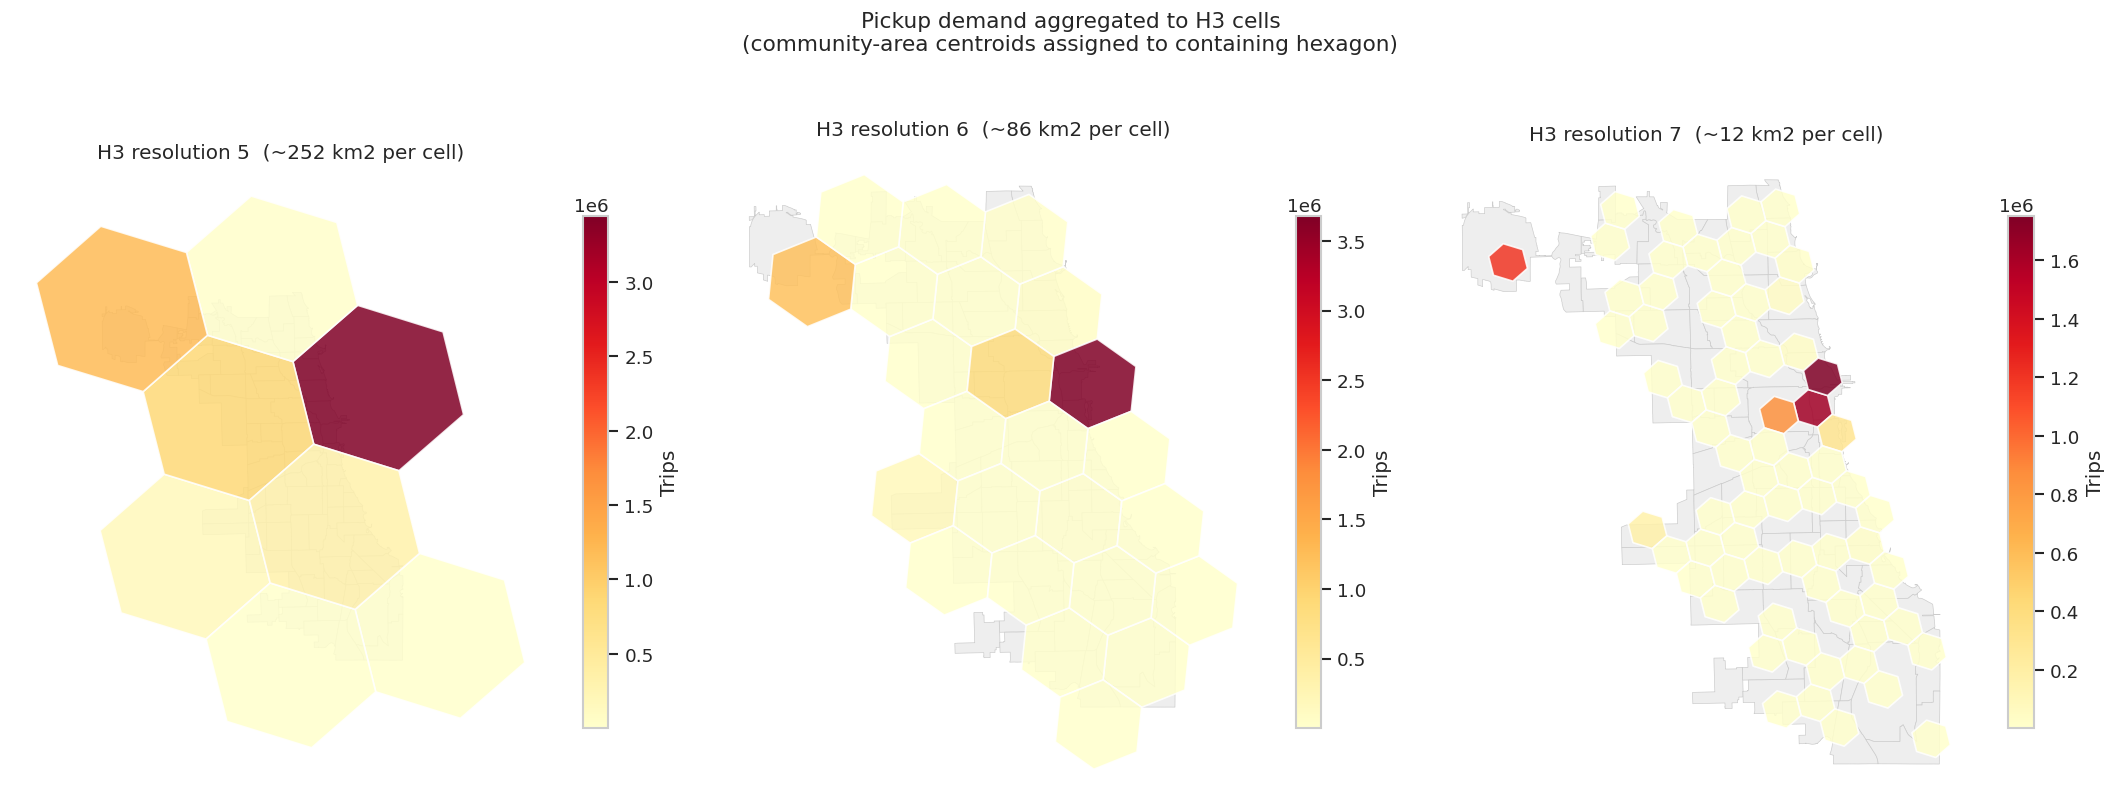

In [16]:
_ca_proj = ca_map.to_crs(epsg=32616)
_centroids = _ca_proj.geometry.centroid.to_crs(epsg=4326)
ca_map['_centroid_lat'] = _centroids.y
ca_map['_centroid_lon'] = _centroids.x

def h3_to_polygon(cell):
    boundary = h3.cell_to_boundary(cell)  # [(lat, lng), ...]
    return Polygon([(lng, lat) for lat, lng in boundary])

res_labels = {5: '~252 km2', 6: '~86 km2', 7: '~12 km2'}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, res in zip(axes, [5, 6, 7]):
    tmp = ca_map.dropna(subset=['_centroid_lat', 'pickup_count']).copy()
    tmp['h3_cell'] = tmp.apply(
        lambda r: h3.latlng_to_cell(r['_centroid_lat'], r['_centroid_lon'], res),
        axis=1
    )
    h3_counts = tmp.groupby('h3_cell')['pickup_count'].sum().reset_index()
    h3_counts['geometry'] = h3_counts['h3_cell'].map(h3_to_polygon)
    gdf_h3 = gpd.GeoDataFrame(h3_counts, geometry='geometry', crs='EPSG:4326')

    ca.plot(ax=ax, color='#eeeeee', edgecolor='#cccccc', linewidth=0.4)
    gdf_h3.plot(column='pickup_count', ax=ax, cmap='YlOrRd', legend=True,
                legend_kwds={'label': 'Trips', 'shrink': 0.7}, alpha=0.85)
    ax.set_title(f'H3 resolution {res}  ({res_labels[res]} per cell)')
    ax.set_axis_off()

plt.suptitle(
    'Pickup demand aggregated to H3 cells\n'
    '(community-area centroids assigned to containing hexagon)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

## 6  Spatio-temporal Cross-analysis

The temporal patterns in Section 1 and the spatial patterns in Section 3 were analysed independently. Here we combine them: for each of the 15 highest-demand community areas, we show how hourly trip volumes distribute across the day.

Two views are provided. The **absolute count heatmap** reveals which area-hour combinations generate the most trips in raw terms. The **row-normalised heatmap** removes the volume effect, expressing each cell as a share of that area's daily total. This allows the temporal *profile* of a low-volume residential neighbourhood to be compared against a high-volume airport or entertainment district on equal footing.

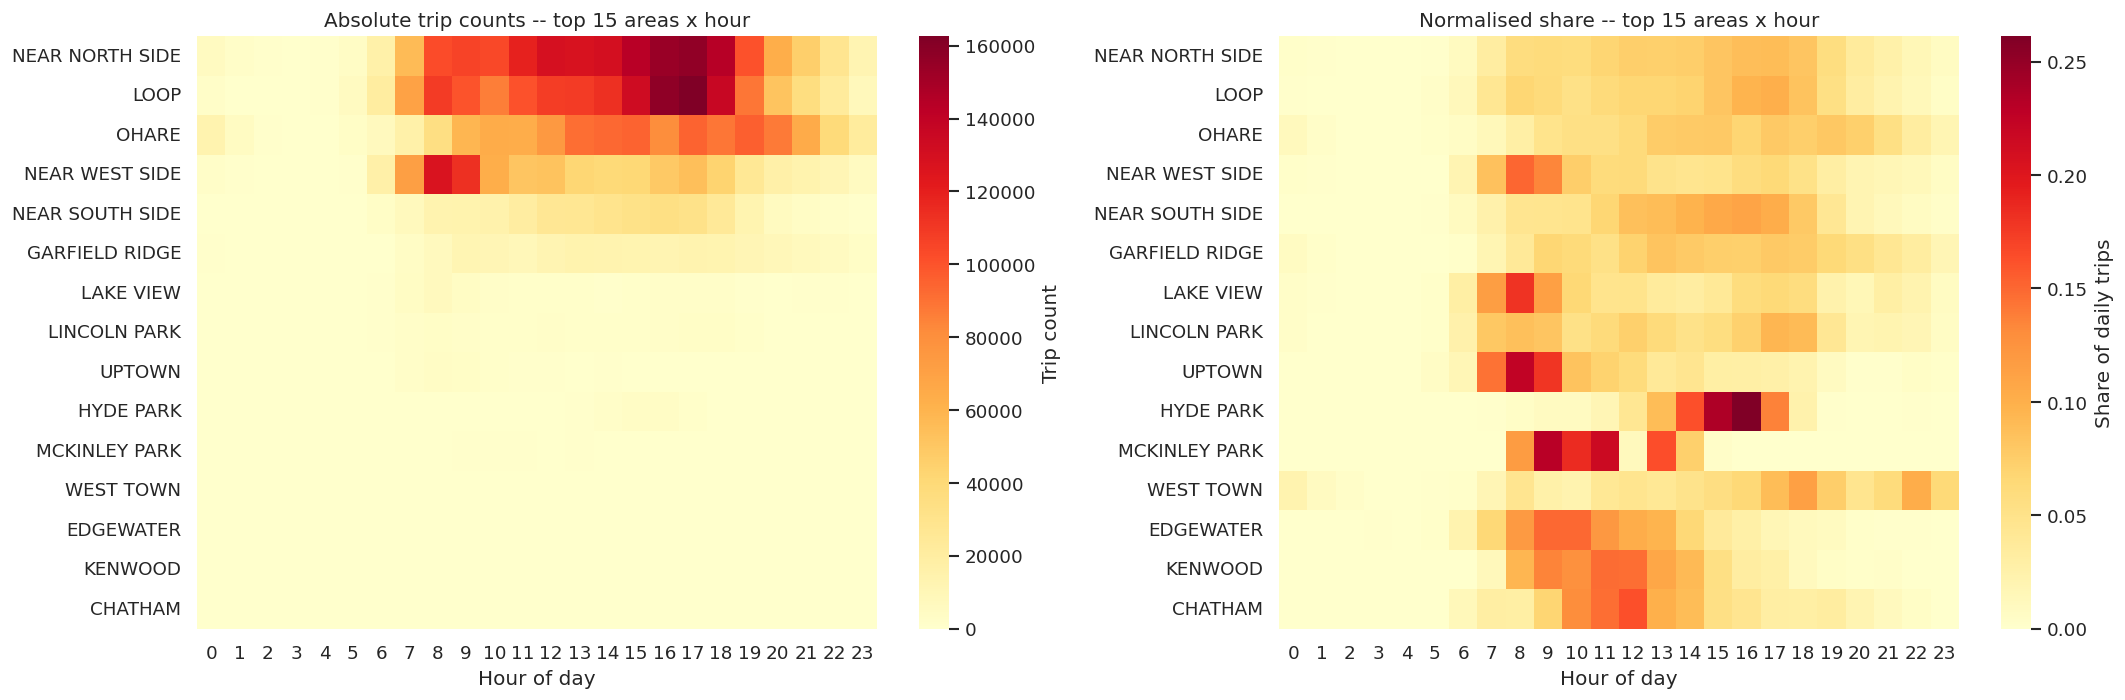

In [13]:
top15 = df['pickup_ca'].value_counts().head(15).index.tolist()

st = (
    df[df['pickup_ca'].isin(top15)]
      .groupby(['pickup_ca', 'pickup_hour'])
      .size()
      .unstack(fill_value=0)
)
st.index = st.index.map(ca_name_map)
st = st.loc[st.sum(axis=1).sort_values(ascending=False).index]

st_norm = st.div(st.sum(axis=1), axis=0)  # row-normalised: share of daily trips

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(st, ax=axes[0], cmap='YlOrRd',
            cbar_kws={'label': 'Trip count'})
axes[0].set_title('Absolute trip counts -- top 15 areas x hour')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('')

sns.heatmap(st_norm, ax=axes[1], cmap='YlOrRd',
            cbar_kws={'label': 'Share of daily trips'})
axes[1].set_title('Normalised share -- top 15 areas x hour')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 7  Hotspot Detection (GMM + KDE)

The choropleth maps in Section 3 reveal demand concentration within administrative boundaries. Here we apply unsupervised learning to identify the underlying hotspot structure without imposing Chicago's community area boundaries.

Two complementary methods are used:

- **Gaussian Mixture Model (GMM)**: fits a weighted mixture of Gaussian distributions to the pickup coordinate cloud. Each component captures one spatial cluster; the 2-sigma ellipses show its geographic extent and orientation. We use BIC to select the number of components *k*, balancing fit quality against model complexity.
- **Kernel Density Estimation (KDE)**: a non-parametric density surface that makes no assumptions about the number or shape of clusters, used here as a sanity check against the parametric GMM.

**Data constraint.** Working with census-tract centroids means the input point cloud consists of a limited set of distinct locations (one per tract), each replicated many times proportional to trip frequency. The GMM and KDE therefore model *where demand is concentrated at census-tract granularity*, not a fine-grained spatial density. We sample 100,000 trips for computational tractability.

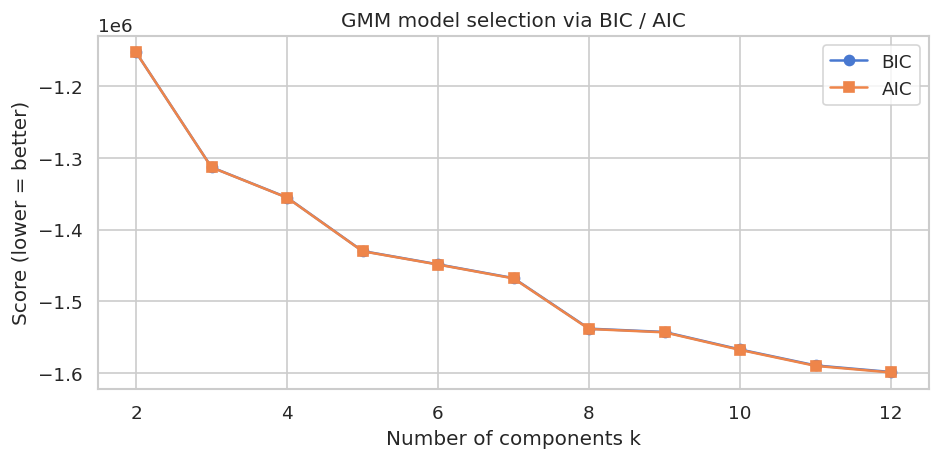

Best k by BIC: 12


In [14]:
# Fit GMM over a range of k; pick best by BIC
# Coordinates in (lon, lat) order so x=lon, y=lat aligns with map plots
sample = (
    df[['pickup_centroid_longitude', 'pickup_centroid_latitude']]
      .dropna()
      .sample(100_000, random_state=42)
      .values
)

k_range = range(2, 13)
bics, aics = [], []
for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(sample)
    bics.append(gmm.bic(sample))
    aics.append(gmm.aic(sample))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), bics, marker='o', label='BIC')
ax.plot(list(k_range), aics, marker='s', label='AIC')
ax.set_xlabel('Number of components k')
ax.set_ylabel('Score (lower = better)')
ax.set_title('GMM model selection via BIC / AIC')
ax.legend()
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmin(bics))]
print(f'Best k by BIC: {best_k}')

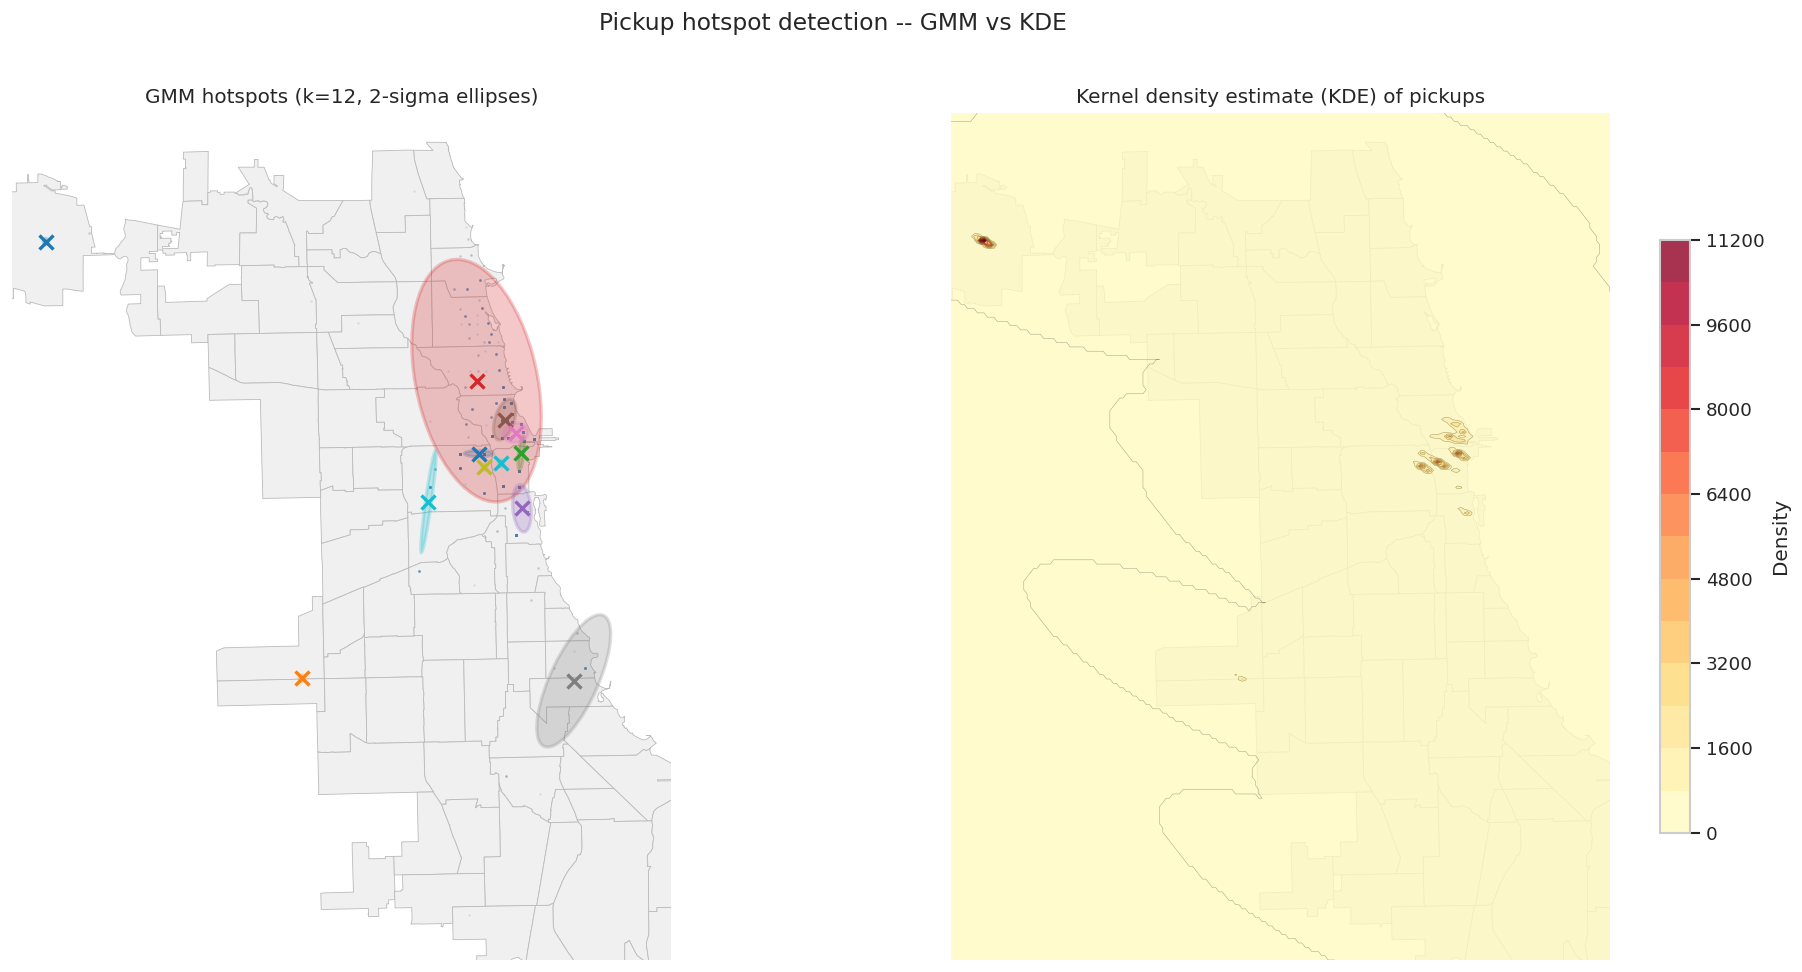

In [15]:
gmm_final = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
gmm_final.fit(sample)

kde = gaussian_kde(sample.T, bw_method=0.03)

lon_min, lon_max = sample[:, 0].min() - 0.02, sample[:, 0].max() + 0.02
lat_min, lat_max = sample[:, 1].min() - 0.02, sample[:, 1].max() + 0.02
lon_g, lat_g = np.meshgrid(
    np.linspace(lon_min, lon_max, 200),
    np.linspace(lat_min, lat_max, 200)
)
kde_vals = kde(np.vstack([lon_g.ravel(), lat_g.ravel()])).reshape(lon_g.shape)

def plot_gmm_ellipse(ax, mean, covar, color):
    v, w = np.linalg.eigh(covar)
    angle = np.degrees(np.arctan2(w[1, 0], w[0, 0]))
    v = 2.0 * np.sqrt(2.0) * np.sqrt(np.abs(v))  # 2-sigma axes
    ell = mpatches.Ellipse(
        xy=mean, width=v[0], height=v[1], angle=angle,
        edgecolor=color, facecolor=color, alpha=0.25, lw=2
    )
    ax.add_patch(ell)
    ax.plot(*mean, 'x', color=color, ms=8, mew=2)

colors_gmm = plt.cm.tab10(np.linspace(0, 1, best_k))

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# GMM panel
ca.plot(ax=axes[0], color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.5)
axes[0].scatter(sample[::10, 0], sample[::10, 1],
                s=0.3, alpha=0.15, color='steelblue', zorder=1)
for k_idx in range(best_k):
    plot_gmm_ellipse(
        axes[0],
        gmm_final.means_[k_idx],
        gmm_final.covariances_[k_idx],
        colors_gmm[k_idx]
    )
axes[0].set_xlim(lon_min, lon_max)
axes[0].set_ylim(lat_min, lat_max)
axes[0].set_title(f'GMM hotspots (k={best_k}, 2-sigma ellipses)', fontsize=12)
axes[0].set_axis_off()

# KDE panel
ca.plot(ax=axes[1], color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.5)
cf = axes[1].contourf(lon_g, lat_g, kde_vals, levels=15, cmap='YlOrRd', alpha=0.8)
axes[1].contour(lon_g, lat_g, kde_vals, levels=15,
                colors='k', linewidths=0.3, alpha=0.4)
plt.colorbar(cf, ax=axes[1], label='Density', shrink=0.7)
axes[1].set_xlim(lon_min, lon_max)
axes[1].set_ylim(lat_min, lat_max)
axes[1].set_title('Kernel density estimate (KDE) of pickups', fontsize=12)
axes[1].set_axis_off()

plt.suptitle('Pickup hotspot detection -- GMM vs KDE', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()